In [ ]:
from pystac_client import Client
import rasterio
import planetary_computer
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

from rasterio import windows, features, warp
from rasterio.features import shapes
from rasterio.enums import Resampling
import rasterio.plot as rplt

from shapely.geometry import box, shape, Polygon
from pyproj import Transformer
import geopandas as gpd

import cv2

import torch
import torch.nn as nn


In [2]:
#Home Centroid
home_lat, home_lon = 39.015025, -77.014889
dc_lat, dc_lon =38.9073, -77.0369

#Setup Datetime
today = str(datetime.now().date())
delay = str(datetime.now().date() - timedelta(days=20))
DATETIME = delay + '/' + today



In [3]:
def point_to_polygon(lat, lon, dim=4000):
    # WGS84 → Web Mercator (meters)
    to_m = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    to_wgs = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

    # convert center point to meters
    x, y = to_m.transform(lon, lat)

    half_size = dim/2 

    # create square in meters
    square = box(
        x - half_size, y - half_size,
        x + half_size, y + half_size
    )

    # convert back to WGS84
    coords = [
        list(to_wgs.transform(px, py))
        for px, py in square.exterior.coords
    ]

    return {
        "type": "Polygon",
        "coordinates": [coords]
    }


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))
        d4 = self.down4(self.pool(d3))

        bn = self.bottleneck(self.pool(d4))

        u4 = self.up4(bn)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)  # logits (IMPORTANT)
    

def load_inference_model(model_path):
    model = UNet() #Create the model
    model.load_state_dict(torch.load(model_path, map_location="cpu"))#Load the model weights
    model.eval()
    return model


In [5]:
class Item:
    def __init__(self, item, aoi):
        self.item = item
        
        #Collect the specific window in the item
        with rasterio.open(item.assets["visual"].href) as ds:
            aoi_bounds = features.bounds(aoi)
            warped_aoi_bounds = warp.transform_bounds("epsg:4326", ds.crs, *aoi_bounds)
            aoi_window = windows.from_bounds(*warped_aoi_bounds, transform=ds.transform)
            self.window = aoi_window.round_offsets().round_lengths()
            self.transform = ds.window_transform(self.window)
            self.crs = ds.crs



    #Function to display the visual of the item
    def get_visual(self):
        #Setup the image
        with rasterio.open(self.item.assets["visual"].href) as ds:
            band_data = ds.read(window=self.window)

        #Format the image for viewing
        img = Image.fromarray(np.transpose(band_data, axes=[1, 2, 0]))
        w = img.size[0]
        h = img.size[1]
        aspect = w / h
        target_w = 800
        target_h = (int)(target_w / aspect)
        img = img.resize((target_w, target_h), Image.Resampling.BILINEAR)

        return img
    

    def get_array(self):
        with rasterio.open(self.item.assets["visual"].href) as ds:
            return ds.read(window=self.window)



    #A function to collect the data from a specific band, not just visual
    def collect_band_data(self, band, shape = None):
        href = self.item.assets[band].href

        with rasterio.open(href) as ds:            
            #Method of reading the data depends on whether we neeed to define the exact shape
            if shape == None:
                return ds.read(1, window=self.window)    
            else:
                return ds.read(
                    1,
                    window = self.window,
                    out_shape = shape,
                    resampling = Resampling.bilinear
                )



    #Function to collect the thermal data for a given item
    #Thermal logic taken from: https://www.sciencedirect.com/science/article/pii/S0924271621001337?via%3Dihub
    def get_thermals(self):
        self.thermal_bands = {}

        self.thermal_bands['B8A'] = self.collect_band_data('B8A')

        ref_shape = self.thermal_bands['B8A'].shape
        for band in ['B11', 'B12']:
            self.thermal_bands[band] = self.collect_band_data(band, shape = ref_shape)

        SWIR1, SWIR2, NIR = self.thermal_bands['B11'], self.thermal_bands['B12'], self.thermal_bands['B8A']

        self.thermal_array1 = (SWIR2 - SWIR1)/NIR
        self.thermal_array2 = (SWIR2 - SWIR1)/(SWIR1 - NIR)

        viewable_array1 = np.clip(self.thermal_array1/20 , 0, 1)
        viewable_array2 = np.clip(self.thermal_array2/20 , 0, 1)

        thermal_view1 = Image.fromarray((viewable_array1 * 255).astype("uint8"))
        thermal_view2 = Image.fromarray((viewable_array2 * 255).astype("uint8"))

        return [thermal_view1, thermal_view2]



    #Method to collect the buildings in the scene
    #Requires input model
    #Returns Mask and Polygons as gpd
    def get_buildings(self, model):
        img = self.get_array()
        

        #-----------------------INFERENCE THE IMAGE--------------------------#
        tile_size = 256
        C, H, W = img.shape

        #Break the image into tiles
        tiles = []
        coords = []
        shape_list = []
        for y in range(0, H, tile_size):
            for x in range(0, W, tile_size):
                tile = img[:, y:y+tile_size, x:x+tile_size]

                c, h, w = tile.shape

                # store original shape
                shape_list.append((h, w))


                padded = np.zeros((c, tile_size, tile_size), dtype=tile.dtype)
                padded[:, :h, :w] = tile

                tiles.append(padded)
                coords.append((y, x))



        #Inference each individual tile
        pred_tiles = []
        for tile in tiles:
            img = torch.tensor(tile / 255.0, dtype=torch.float32).unsqueeze(0)

            with torch.no_grad():
                output = model(img)

            pred = (output.squeeze().numpy() > 0.5).astype(np.uint8)
            pred_tiles.append(pred)



        #-----------------------CREATE THE MASK--------------------------#
        #Stitch the output tiles back together into one mask
        #This step removes the padding placed before inference
        full_mask = np.zeros((H, W), dtype=np.uint8)

        for (y, x), pred, (h, w) in zip(coords, pred_tiles, shape_list):
            full_mask[y:y+h, x:x+w] = pred[:h, :w]

        #Cleam up the mask (fill holes and eliminate noise)
        full_mask = full_mask.astype(np.uint8)

        # remove small noise
        kernel = np.ones((2,2), np.uint8)
        full_mask = cv2.morphologyEx(full_mask, cv2.MORPH_OPEN, kernel)

        # fill small holes
        full_mask = cv2.morphologyEx(full_mask, cv2.MORPH_CLOSE, kernel)




        #-----------------------CREATE THE POLYGONS--------------------------#
        num_labels, labels = cv2.connectedComponents(full_mask)

        polygons = []
        #Pull out all the labeled pixels
        for label in range(1, num_labels):  # skip background (0)
            component = (labels == label).astype(np.uint8)

            contours, _ = cv2.findContours(
                component,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            #Stitch pixels into polygons
            for cnt in contours:
                if len(cnt) >= 3:
                    poly = Polygon(cnt.squeeze())
                    polygons.append(poly)


        #Convert Polygons to geospatially informed polygons
        geo_polygons = []
        for geom, value in shapes(full_mask, transform=self.transform):
            if value == 1:
                geo_polygons.append(shape(geom))

        #Push into GeoPandas DF for storage/access
        gdf = gpd.GeoDataFrame(geometry=geo_polygons, crs=self.crs)


        #-----------------------RETURN MASK & POLYGONS--------------------------#
        return full_mask, gdf
    

In [6]:
class ObservedArea:
    def __init__(self, aoi, datetime):
        self.aoi = aoi
        self.datetime = datetime

        self.get_items()


    #Function to collect the items associated with that area during that time
    def get_items(self):
        self.items = []
        
        catalog = Client.open(
            "https://planetarycomputer.microsoft.com/api/stac/v1",
            modifier = planetary_computer.sign_inplace)

        #Setup the Search
        search = catalog.search(
            collections=["sentinel-2-l2a"],
            intersects=self.aoi,
            datetime=self.datetime
        )

        #Collect the items and save as class Item in list
        item_names = list(search.get_items())
        for name in item_names: self.items.append(Item(name, self.aoi))


In [7]:
def tile_and_inference(image, model):
    tile_size = 256
    C, H, W = image.shape

    #Break the image into tiles
    tiles = []
    coords = []
    shape_list = []
    for y in range(0, H, tile_size):
        for x in range(0, W, tile_size):
            tile = image[:, y:y+tile_size, x:x+tile_size]

            c, h, w = tile.shape

            # store original shape
            shape_list.append((h, w))


            padded = np.zeros((c, tile_size, tile_size), dtype=tile.dtype)
            padded[:, :h, :w] = tile

            tiles.append(padded)
            coords.append((y, x))



    #Inference each individual tile
    pred_tiles = []
    for tile in tiles:
        img = torch.tensor(tile / 255.0, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            output = model(img)

        pred = (output.squeeze().numpy() > 0.5).astype(np.uint8)
        pred_tiles.append(pred)





    #Stitch the output tiles back together into one mask
    #This step removes the padding placed before inference
    full_mask = np.zeros((H, W), dtype=np.uint8)

    for (y, x), pred, (h, w) in zip(coords, pred_tiles, shape_list):
        full_mask[y:y+h, x:x+w] = pred[:h, :w]


    return full_mask

/opt/homebrew/anaconda3/envs/sentinelenv/lib/python3.14/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


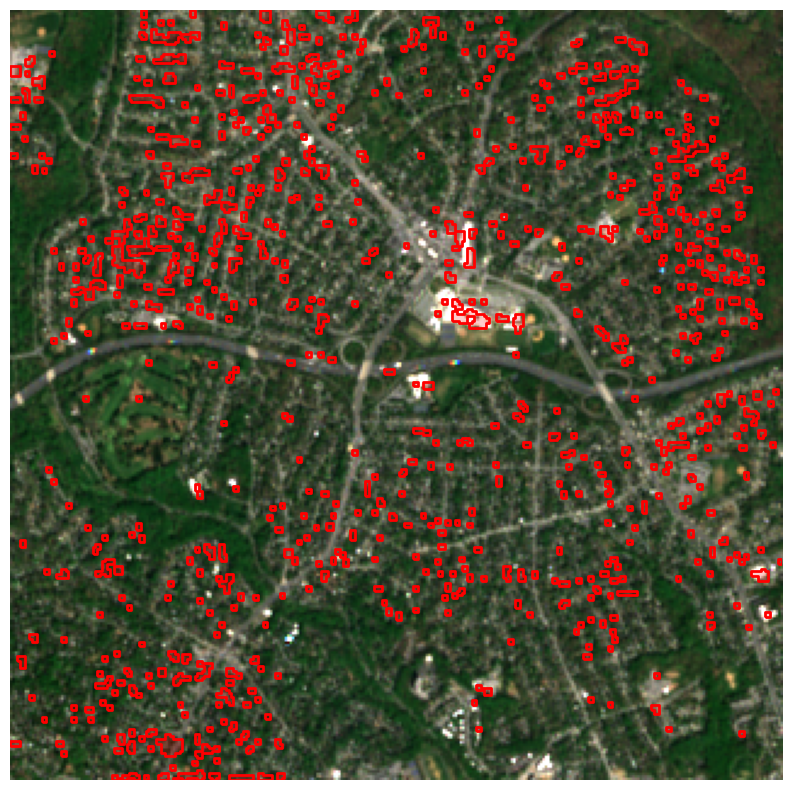

In [8]:
aoi = point_to_polygon(home_lat, home_lon, dim = 4000)

obs = ObservedArea(aoi, DATETIME)

item1 = obs.items[1]


#Setup the Model
model = load_inference_model("best_model.pth")

image = item1.get_array()
mask, gdf = item1.get_buildings(model)

fig, ax = plt.subplots(figsize=(10, 10))

rplt.show(image, transform=item1.transform, ax=ax)


# plot directly in geospatial space
gdf.boundary.plot(ax=ax, color="red", linewidth=2)
gdf.plot(ax=ax, color="red", alpha=0.2)

plt.axis("off")
plt.show()

In [9]:
print("complete")

complete
